In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

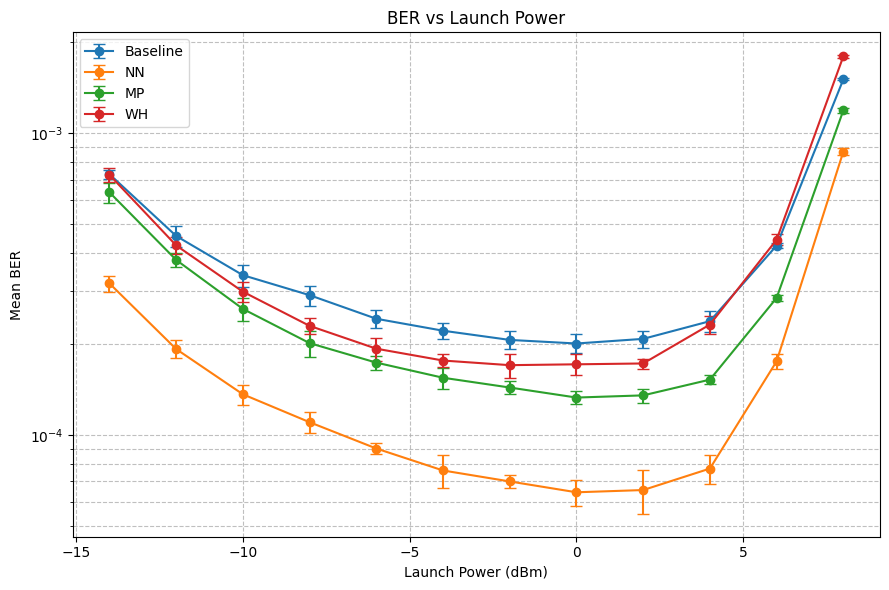

        Case  Launch_Power_dBm  mean_BER   std_BER  trials
0   Baseline             -14.0  0.000730  0.000026       5
1   Baseline             -12.0  0.000456  0.000037       5
2   Baseline             -10.0  0.000338  0.000028       5
3   Baseline              -8.0  0.000290  0.000022       5
4   Baseline              -6.0  0.000242  0.000017       5
5   Baseline              -4.0  0.000221  0.000014       5
6   Baseline              -2.0  0.000206  0.000014       5
7   Baseline               0.0  0.000201  0.000014       5
8   Baseline               2.0  0.000208  0.000013       5
9   Baseline               4.0  0.000238  0.000019       5
10  Baseline               6.0  0.000423  0.000008       5
11  Baseline               8.0  0.001504  0.000011       5
12        NN             -14.0  0.000317  0.000020       5
13        NN             -12.0  0.000192  0.000013       5
14        NN             -10.0  0.000136  0.000010       5
15        NN              -8.0  0.000110  0.000008      

In [8]:
FILES = {
    "Baseline": "FINAL_results_NoDPD_BER_vs_Launch_Power.csv",
    "NN": "FINAL_results_DPD_BER_vs_Launch_Power.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_launch_power.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Launch_Power.csv",
}

BASE_DIR = Path.cwd()

all_summaries = []

plt.figure(figsize=(9, 6))

for case, filename in FILES.items():
    df = pd.read_csv(BASE_DIR / filename)

    # Handle different launch power column names
    if "P_launch_dBm" in df.columns:
        df = df.rename(columns={"P_launch_dBm": "Launch_Power_dBm"})
    elif "Launch Power" in df.columns:
        df = df.rename(columns={"Launch Power": "Launch_Power_dBm"})

    summary = (
        df.groupby("Launch_Power_dBm")
        .agg(
            mean_BER=("BER", "mean"),
            std_BER=("BER", "std"),
            trials=("BER", "count"),
        )
        .reset_index()
        .sort_values("Launch_Power_dBm")
    )

    summary["std_BER"] = summary["std_BER"].fillna(0)

    summary.insert(0, "Case", case)

    all_summaries.append(summary)

    plt.errorbar(
        summary["Launch_Power_dBm"],
        summary["mean_BER"],
        yerr=summary["std_BER"],
        marker="o",
        capsize=4,
        label=case,
    )

final_summary = pd.concat(all_summaries, ignore_index=True)

final_summary.to_csv(BASE_DIR / "ber_mean_std_summary.csv", index=False)

plt.yscale("log")
plt.xlabel("Launch Power (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Launch Power")
plt.grid(True, which="both", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()

plt.savefig(BASE_DIR / "ber_vs_launch_power_all_cases.png", dpi=300)
plt.show()

print(final_summary)



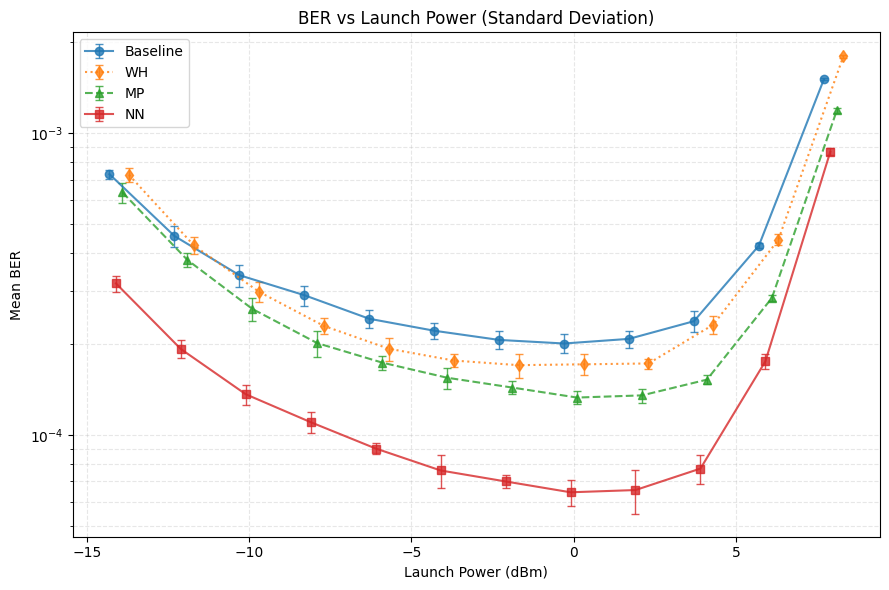

In [9]:
offsets = {
    "Baseline": -0.3,
    "NN": -0.1,
    "MP": 0.1,
    "WH": 0.3,
}

styles = {
    "Baseline": {"marker": "o", "linestyle": "-"},
    "NN": {"marker": "s", "linestyle": "-"},
    "MP": {"marker": "^", "linestyle": "--"},
    "WH": {"marker": "d", "linestyle": ":"},
}

plt.figure(figsize=(9, 6))

for case in ["Baseline", "WH", "MP", "NN"]:
    summary = next(s for s in all_summaries if s["Case"].iloc[0] == case)

    x = summary["Launch_Power_dBm"] + offsets[case]

    plt.errorbar(
        x,
        summary["mean_BER"],
        yerr=summary["std_BER"],
        capsize=3,
        elinewidth=1,
        markersize=6,
        alpha=0.8,
        label=case,
        **styles[case]
    )

plt.yscale("log")
plt.xlabel("Launch Power (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Launch Power (Standard Deviation)")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import ttest_ind
import pandas as pd

# Load your full raw data (not the summary!)
# IMPORTANT: this must be the raw trial data CSVs

FILES = {
    "Baseline": "FINAL_results_NoDPD_BER_vs_Launch_Power.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Launch_Power.csv",
}

BASE_DIR = Path.cwd()

dfs = {}
for case, file in FILES.items():
    df = pd.read_csv(BASE_DIR / file)

    if "P_launch_dBm" in df.columns:
        df = df.rename(columns={"P_launch_dBm": "Launch_Power_dBm"})
    elif "Launch Power" in df.columns:
        df = df.rename(columns={"Launch Power": "Launch_Power_dBm"})

    dfs[case] = df

results = []

# Loop through each launch power
for power in sorted(dfs["Baseline"]["Launch_Power_dBm"].unique()):

    baseline_vals = dfs["Baseline"][
        dfs["Baseline"]["Launch_Power_dBm"] == power
    ]["BER"]

    wh_vals = dfs["WH"][
        dfs["WH"]["Launch_Power_dBm"] == power
    ]["BER"]

    t_stat, p_value = ttest_ind(baseline_vals, wh_vals, equal_var=False)

    results.append({
        "Launch_Power_dBm": power,
        "t_stat": t_stat,
        "p_value": p_value
    })

results_df = pd.DataFrame(results)
print(results_df)

    Launch_Power_dBm     t_stat       p_value
0                -14   0.186584  8.572399e-01
1                -12   1.546198  1.635061e-01
2                -10   2.476875  3.942463e-02
3                 -8   5.178746  1.430863e-03
4                 -6   4.580697  1.803320e-03
5                 -4   6.158316  4.979522e-04
6                 -2   3.853650  5.013999e-03
7                  0   3.318989  1.058906e-02
8                  2   5.342617  1.958750e-03
9                  4   0.558440  5.921822e-01
10                 6  -2.128063  8.161668e-02
11                 8 -32.854849  4.775316e-09


In [10]:
from scipy.stats import ttest_ind
import pandas as pd
from pathlib import Path

FILES = {
    "Baseline": "FINAL_results_NoDPD_BER_vs_Launch_Power.csv",
    "NN": "FINAL_results_DPD_BER_vs_Launch_Power.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_launch_power.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Launch_Power.csv",
}

BASE_DIR = Path.cwd()

# Load data
dfs = {}
for case, file in FILES.items():
    df = pd.read_csv(BASE_DIR / file)

    if "P_launch_dBm" in df.columns:
        df = df.rename(columns={"P_launch_dBm": "Launch_Power_dBm"})
    elif "Launch Power" in df.columns:
        df = df.rename(columns={"Launch Power": "Launch_Power_dBm"})

    dfs[case] = df

results = []

powers = sorted(dfs["Baseline"]["Launch_Power_dBm"].unique())

# Loop through each power and each method
for power in powers:

    baseline_vals = dfs["Baseline"][
        dfs["Baseline"]["Launch_Power_dBm"] == power
    ]["BER"]

    for method in ["NN", "MP", "WH"]:

        method_vals = dfs[method][
            dfs[method]["Launch_Power_dBm"] == power
        ]["BER"]

        t_stat, p_value = ttest_ind(
            baseline_vals, method_vals, equal_var=False
        )

        results.append({
            "Launch_Power_dBm": power,
            "Method": method,
            "t_stat": t_stat,
            "p_value": p_value,
            "Significant": p_value < 0.05
        })

results_df = pd.DataFrame(results)

# Optional: sort nicely
results_df = results_df.sort_values(["Method", "Launch_Power_dBm"])

pivot = results_df.pivot(
    index="Launch_Power_dBm",
    columns="Method",
    values="p_value"
)

print(pivot)


Method                      MP            NN            WH
Launch_Power_dBm                                          
-14               7.438592e-03  8.206698e-09  8.572399e-01
-12               6.104440e-03  2.184166e-05  1.635061e-01
-10               1.609877e-03  2.111563e-05  3.942463e-02
-8                1.567133e-04  1.007135e-05  1.430863e-03
-6                2.005395e-04  2.151182e-05  1.803320e-03
-4                4.199901e-05  2.074556e-07  4.979522e-04
-2                1.004364e-04  9.843348e-06  5.013999e-03
 0                1.069045e-04  2.814819e-06  1.058906e-02
 2                3.312875e-05  1.231930e-07  1.958750e-03
 4                2.668830e-04  3.841640e-06  5.921822e-01
 6                5.416621e-09  1.881005e-10  8.161668e-02
 8                1.749933e-08  2.049698e-09  4.775316e-09
